Persistence 

1. short term memory 
2. Fault Tolerence
3. Human in the Loop (HITL)
4. Time Travel

In [2]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [3]:

load_dotenv()

True

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
) 


In [5]:

class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [6]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:

def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [8]:

graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

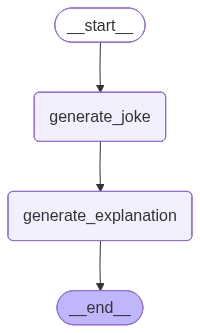

In [9]:
workflow

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)


{'topic': 'pizza',
 'joke': 'Why did the pizza maker break up with his girlfriend?\n\nBecause he said, "I don\'t *knead* you anymore!"',
 'explanation': 'This joke is a classic example of a **pun**!\n\nHere\'s why it\'s funny:\n\n1.  **"Knead" (as in pizza dough):** For a pizza maker, "to knead" is a very specific and essential action. It means to work and press dough with your hands, usually to develop gluten and give the dough elasticity and structure. Pizza dough definitely needs to be kneaded.\n\n2.  **"Need" (as in relationship):** When someone says "I don\'t *need* you anymore" in a relationship, it\'s a common and direct way to end things. It means "I no longer require your presence, support, or partnership in my life."\n\nThe joke plays on the fact that **"knead" and "need" are homophones** – they sound exactly alike but have different meanings and spellings.\n\nSo, the pizza maker uses a word directly related to his profession ("knead" the dough), but it sounds exactly like th

In [13]:
workflow.get_state(config1)


StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker break up with his girlfriend?\n\nBecause he said, "I don\'t *knead* you anymore!"', 'explanation': 'This joke is a classic example of a **pun**!\n\nHere\'s why it\'s funny:\n\n1.  **"Knead" (as in pizza dough):** For a pizza maker, "to knead" is a very specific and essential action. It means to work and press dough with your hands, usually to develop gluten and give the dough elasticity and structure. Pizza dough definitely needs to be kneaded.\n\n2.  **"Need" (as in relationship):** When someone says "I don\'t *need* you anymore" in a relationship, it\'s a common and direct way to end things. It means "I no longer require your presence, support, or partnership in my life."\n\nThe joke plays on the fact that **"knead" and "need" are homophones** – they sound exactly alike but have different meanings and spellings.\n\nSo, the pizza maker uses a word directly related to his profession ("knead" the dough), but it sou

In [14]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza maker break up with his girlfriend?\n\nBecause he said, "I don\'t *knead* you anymore!"', 'explanation': 'This joke is a classic example of a **pun**!\n\nHere\'s why it\'s funny:\n\n1.  **"Knead" (as in pizza dough):** For a pizza maker, "to knead" is a very specific and essential action. It means to work and press dough with your hands, usually to develop gluten and give the dough elasticity and structure. Pizza dough definitely needs to be kneaded.\n\n2.  **"Need" (as in relationship):** When someone says "I don\'t *need* you anymore" in a relationship, it\'s a common and direct way to end things. It means "I no longer require your presence, support, or partnership in my life."\n\nThe joke plays on the fact that **"knead" and "need" are homophones** – they sound exactly alike but have different meanings and spellings.\n\nSo, the pizza maker uses a word directly related to his profession ("knead" the dough), but it so

In [15]:

config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta get arrested?\n\nBecause it was an **impasta**!',
 'explanation': 'This joke is a classic example of a **pun**, which is a form of wordplay that exploits multiple meanings of a word or of similar-sounding words.\n\nHere\'s the breakdown:\n\n1.  **"Impasta" sounds exactly like "imposter."**\n2.  An **imposter** is a person who pretends to be someone else in order to deceive or defraud.\n3.  The setup of the joke, "Why did the pasta get arrested?", implies some kind of wrongdoing or crime (like impersonation, which an imposter commits).\n4.  So, the humor comes from the silly idea that the pasta was arrested not for being actual pasta, but for *pretending* to be something it wasn\'t – an "imposter" – using the clever twist of including "pasta" in the sound-alike word.\n\nIt\'s a simple, groan-worthy pun that relies on the phonetic similarity between "impasta" and "imposter."'}

In [13]:
workflow.get_state(config1)


StateSnapshot(values={'topic': 'pizza', 'joke': 'What kind of advice does a pizza give?\n\nA *slice* of advice!', 'explanation': 'This joke is a classic pun that plays on two key ideas:\n\n1.  **The literal connection to pizza:** A pizza is typically cut into **slices**. So, if a pizza were to "give" something, it would literally be a slice.\n\n2.  **The sound-alike idiom:** The phrase "a **slice** of advice" sounds almost identical to the very common English idiom "a **piece** of advice." We often say, "Can I give you a piece of advice?"\n\nThe humor comes from the clever combination of these two elements. The joke sets you up to think about what a pizza gives, and then delivers an answer that is both literally true in the context of pizza and sounds like a common way to refer to counsel.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7107-6247-6030-8002-54a506e2ade1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_a

In [14]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'pizza', 'joke': 'What kind of advice does a pizza give?\n\nA *slice* of advice!', 'explanation': 'This joke is a classic pun that plays on two key ideas:\n\n1.  **The literal connection to pizza:** A pizza is typically cut into **slices**. So, if a pizza were to "give" something, it would literally be a slice.\n\n2.  **The sound-alike idiom:** The phrase "a **slice** of advice" sounds almost identical to the very common English idiom "a **piece** of advice." We often say, "Can I give you a piece of advice?"\n\nThe humor comes from the clever combination of these two elements. The joke sets you up to think about what a pizza gives, and then delivers an answer that is both literally true in the context of pizza and sounds like a common way to refer to counsel.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7107-6247-6030-8002-54a506e2ade1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_

Fault Tolerence

In [15]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [16]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [17]:

# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [18]:

# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)


checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:

try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

In [ ]:

# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)

In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))